# Solar Energy and Equity 😎

### How can we model potential effects of household solar panels on energy burden in the United States?

🌞 This Python notebook will teach you the following!
*   Importing and exploring data with **Pandas**
*   Graphing with **Matplotlib** and **Seaborn**
*   Creating basic predictive models using **Numpy** and **Scikit-learn**


## 1 - Intro to Python Notebook

Google Colab is an environment to execute Python from your browser! This is similar to the industry standard Jupyter Notebooks, except a limited kernel and memory is provided.

If you would like to learn better, turn off AI mode! **Tools --> Settings --> AI mode --> Uncheck boxes**

In [ ]:
tutorial = "Press the play button to the left or 'Shift + Enter' or 'Command/Ctrl + Enter' to run a code cell"

In [ ]:
print("Make sure to run previous cells to use previously defined variables!")
print(tutorial)

In [ ]:
# organize your code with comments!

## 2 - Import Data

*   Pandas is a "library" or "software package" that already exists for us to import and use. Pandas is used for importing, cleaning, and manipulating data.
*   You can read in the file directly by downloading it from the source ([Figshare](https://figshare.com/articles/dataset/Modeling_potential_effects_of_rooftop_solar_on_household_energy_burden_in_the_United_States/25130498?file=45843111)) and dragging and dropping it into the file icon on the left. However, to make this quicker, I compiled the data into source links so you don't have to download it!
*   This is a real-world dataset from all U.S. regions from 2013-2021!






In [ ]:
import pandas as pd

In [ ]:
eb_data_path = "https://github.com/nimi-nair/solar_and_energy_burden_model/raw/refs/heads/main/difference_in_energy_burden.xlsx"

# read in sheet 1 into a variable called eb
...

In [ ]:
eb

## 3 - Data Cleaning

*   Convert the 'Difference in EB' column to percentage points by multiplying by 100.
*   Then, delete the original 'Difference in EB' column.

In [ ]:
# convert 'Difference in EB' to percentage points and store into a new column

eb['Difference in EB [% points]'] = ...
eb = eb.drop('Difference in EB', axis=1)
eb

## 4 - Exploratory Data Analysis

Exploratory Data Analysis (EDA) is your chance to explore the data in whatever ways you want! This can include looking at statistical values and making tons of graphs. The goal is to see what our data can tell us (what patterns/trends it shows). This can inform what kinds of predictive models we may want to make in the future.

Often, with real-world data, things we try will be inconclusive. It takes a while to uncover patterns sometimes.

## 4.1 - EDA: How does income type affect difference in environmental burden (EB)?

*   Which columns of the dataframe should we use?
*   How do we find the average "Difference in EB" per "LMI" category (income group)?
*   What graph should we plot this in?





In [ ]:
# How does income type affect difference in EB?

# Aggregate by LMI category and find the average 'Difference in EB' per category
# dataframe.groupby(category-to-group)[column-to-aggregate].aggregation_function()

groupby_LMI = eb.groupby(...)[...].mean()
groupby_LMI

**Note**: Matplotlib is the Python library used for all sorts of plots. You never need to memorize how to do anything. Check out this comprehensive [graphing tutorial page](https://matplotlib.org/stable/gallery/index.html)!

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
# bar plot from dataframe
groupby_LMI.plot(x=..., y=..., kind='bar')

# some plotting details, including title and axes labels
plt.title('Average Difference in Environmental Burden per Income Group')
plt.xlabel('Income Group')
plt.ylabel('EB Difference')
plt.xticks(rotation=0)

plt.show()

## 4.2 - EDA: How do we group by BOTH income and heating fuel type?

In [ ]:
# combining income and heating fuel type findings

# create a pivot table!
pivot = eb.pivot_table(
    index=...,
    columns=...,
    values=...,
    aggfunc=...
)

pivot

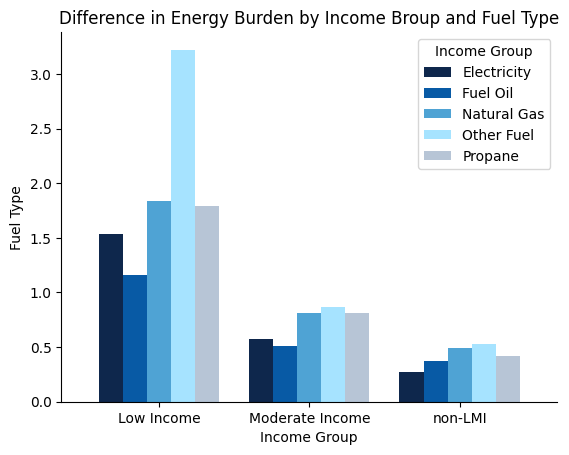

In [ ]:
# Now let's plot it in a grouped bar chart!

colors = ["#0e274cff", "#085aa5ff", "#4fa3d4", "#a6e3ffff", "#b7c5d6"]

ax = pivot.plot(kind='bar', width=0.8, color=colors)

ax.set_title('Difference in Energy Burden by Income Broup and Fuel Type')
ax.set_xlabel('Income Group')
ax.set_ylabel('Fuel Type')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend(title='Income Group')
ax.tick_params(axis='x', rotation=0)

plt.show()

## 4.3 - EDA: Explore how EB changes over time based on income group

Next, let's import another sheet from our source excel file with information on how EB changes over time.

In [ ]:
# read in sheet 5 (might take a minute or two)
eb_over_time_path = "https://github.com/nimi-nair/solar_and_energy_burden_model/raw/refs/heads/main/energy_burden_over_time.xlsx"
eb_over_time = pd.read_excel(eb_over_time_path, nrows=10000)

In [ ]:
eb_over_time

In [ ]:
# add a new column "Difference in EB" calculated based on EB absent solar and EB with solar (remember to multiply by 100 to convert to percentage points)

...
eb_over_time

In [ ]:
# create a pivot table to group by both LMI and year

pivot_2 = eb_over_time.pivot_table(
    index=...,
    columns=...,
    values=...,
    aggfunc=...
)

pivot_2

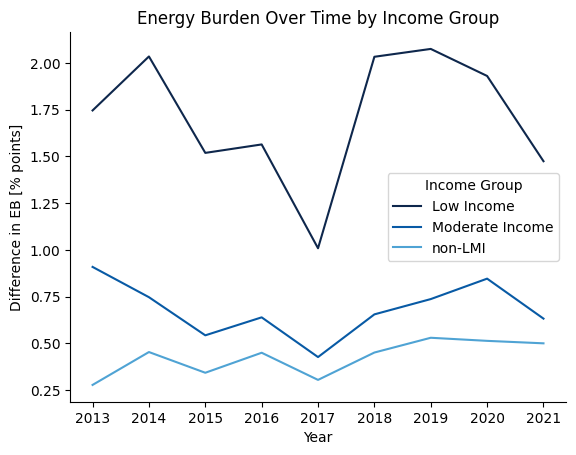

In [ ]:
# plot in a line graph!!

...

## 5 - Modeling: Simple Linear Regression

Predictive modeling uses trends in data to predict future outcomes. A simple example is plotting a line: y = mx + b.

For example, looking at the same dataset (eb_over_time), we see that EB absent solar and EB with solar have a linear relationship.

In [ ]:
eb_over_time

,LMI,Year of adoption,EB absent solar,EB with solar
0,non-LMI,2019,0.019834,0.019302
1,non-LMI,2014,0.019049,0.012743
2,Low Income,2013,0.064798,0.044067
3,non-LMI,2017,0.015666,0.009880
4,non-LMI,2018,0.044038,0.016095
...,...,...,...,...
9995,non-LMI,2017,0.022408,0.019474
9996,non-LMI,2015,0.028928,0.026143
9997,non-LMI,2015,0.029859,0.029435
9998,non-LMI,2019,0.019301,0.017453


**Note**: numpy is a library used for more complex mathematical and statistical computing. Here, we can use it to fit our linear regression model to our data.

In [ ]:
import numpy as np

Equation: y = 0.8972597300303051x + -0.002130191938194405


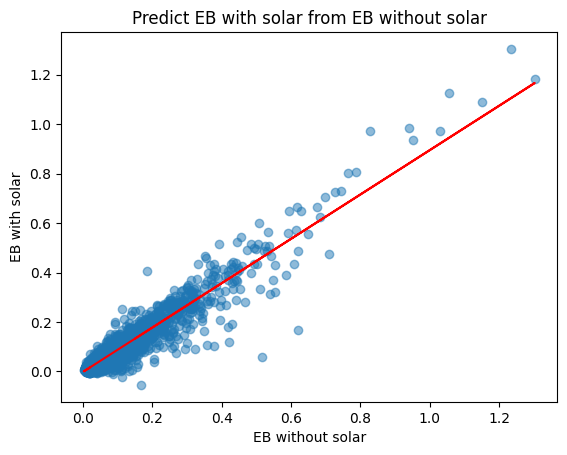

In [ ]:
x = eb_over_time['EB absent solar']
y = eb_over_time['EB with solar']

# Fit linear regression
slope, intercept = np.polyfit(x, y, 1)

# Plot points and regression line
plt.scatter(x, y, alpha=0.5)
plt.plot(x, np.array(x)*slope + intercept, color='red')

print(f"Equation: y = {slope}x + {intercept}")

plt.xlabel('EB without solar')
plt.ylabel('EB with solar')
plt.title('Predict EB with solar from EB without solar')
plt.show()

## 5.1 - How can we use Mean Squared Error (MSE) to understand the performance of our model?

Mean Squared Error (MSE) is a metric that measures the average squared difference between observed and predicted values. Numpy will do all the calculations for us, but here's the formula FYI:

$$ \text{MSE}(y, \hat{y}) = \frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2 $$

In [ ]:
y_true = np.array(y.tolist()) # converting actual values to numpy array
y_pred = slope * np.array(x.tolist()) + intercept # calculating predicted values

# using numpy to find mse
mse = np.mean((y_true - y_pred)**2)
mse

np.float64(0.0003947529637810284)

## 5.2 - Compare MSE to the variance of our data.


*   Our MSE doesn't tell us much on it's own. We need to contextualize it to our data by comparing it to the variance.
*   Variance measures how spread out our data is, calculated as the average of the squared differences from the mean.
*   If the MSE is much smaller than the variance, the model performs well!

In [ ]:
var_y = np.var(y_true, ddof=0)
var_y

np.float64(0.00424632228509279)

In [ ]:
# ratio of mse to var
ratio = 1 - mse/var_y
print(f"The model explains {ratio * 100}% of variance in 'EB with solar'!")

The model explains 90.70365042317079% of variance in 'EB with solar'!


## 6 - Modeling: More Complex!

What if our dataset is not just x and y, but instead many x's to predict one y? We can model this in a similar way, using multiple linear regression!

Let's read in another dataset. Due to the limitations on our real-world data, this is a synthetic dataset that suits our purposes better.

In [ ]:
# Let's say our dataset looks more like this
model_eb_path = "https://github.com/nimi-nair/solar_and_energy_burden_model/raw/refs/heads/main/model_eb_dataset.csv"
model_eb_data = pd.read_csv(model_eb_path)

In [ ]:
model_eb_data

,Roof_Size [sq ft],Energy_Usage [kWh/yr],State,Income_Group,Region,Primary_Heating_Fuel,Change_in_EB [% points]
0,2248.357077,14198.066310,IL,Moderate,Midwest,Heating Oil,5.937662
1,1930.867849,12773.901049,WA,Low,West,Natural Gas,2.553538
2,2323.844269,10178.891110,IL,Low,Midwest,Heating Oil,3.379729
3,2761.514928,8059.189667,NY,Moderate,Northeast,Electricity,0.034019
4,1882.923313,12094.669941,NY,Low,Northeast,Heating Oil,5.783962
...,...,...,...,...,...,...,...
995,1859.449854,13210.450715,FL,Moderate,South,Electricity,3.708929
996,2898.843263,9920.436222,CA,Moderate,West,Electricity,3.520156
997,2320.421431,7354.376046,CA,Moderate,West,Electricity,1.882299
998,1714.410505,9510.799108,NY,Moderate,Northeast,Natural Gas,0.226394


## 6.1 - It's your turn to explore this dataset with some EDA

*   Here, the goal would be to use the columns (aka features) of Roof Size, Energy Usage, Income Group, Region, and Primary Heating Fuel (or x variables) to predict Change in Energy Burden (our y variable).
*   Explore the relationships between a couple of variables by aggregating, averaging, and plotting as your heart desires


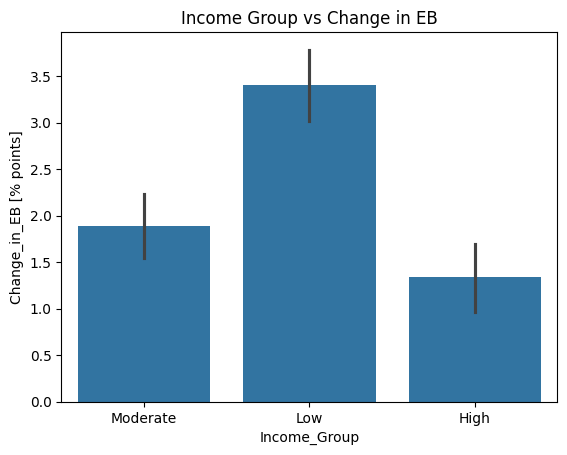

In [ ]:
sns.barplot(x="Income_Group", y="Change_in_EB [% points]", data=model_eb_data)
plt.title("Income Group vs Change in EB")
plt.show()

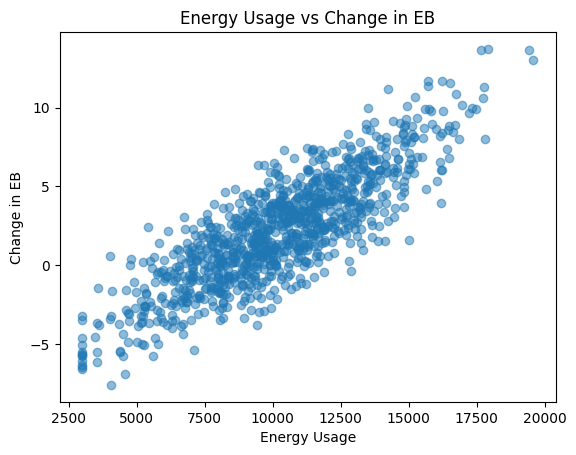

In [ ]:
plt.scatter(model_eb_data["Energy_Usage [kWh/yr]"], model_eb_data["Change_in_EB [% points]"], alpha=0.5)
plt.xlabel("Energy Usage")
plt.ylabel("Change in EB")
plt.title("Energy Usage vs Change in EB")
plt.show()

## 6.2 - What does this heatmap tell us?

The color variations show us the correlations between all the quantitative variables in our dataset. Which variables have positive or negative correlations? Which variables have strong correlations?

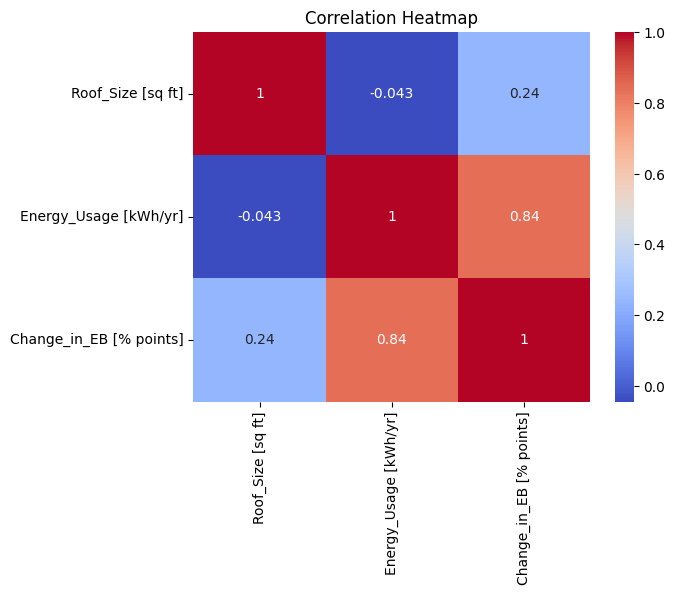

In [ ]:
sns.heatmap(model_eb_data[["Roof_Size [sq ft]","Energy_Usage [kWh/yr]","Change_in_EB [% points]"]].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## 6.3 - Multiple Linear Regression

Scikit-learn (sklearn) is yet another library that provides all sorts of models (including linear regression which we are using). It also has some handy tools for data pre-processing.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
# Target
y = model_eb_data["Change_in_EB [% points]"]

# Features (drop target)
X = model_eb_data.drop(columns=["Change_in_EB [% points]"])

# One-hot encode categorical variables
X = pd.get_dummies(X, drop_first=True)

X

,Roof_Size [sq ft],Energy_Usage [kWh/yr],State_CA,State_FL,State_IL,State_MA,State_NY,State_TX,State_WA,Income_Group_Low,Income_Group_Moderate,Region_Northeast,Region_South,Region_West,Primary_Heating_Fuel_Heating Oil,Primary_Heating_Fuel_Natural Gas,Primary_Heating_Fuel_Other
0,2248.357077,14198.066310,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False
1,1930.867849,12773.901049,False,False,False,False,False,False,True,True,False,False,False,True,False,True,False
2,2323.844269,10178.891110,False,False,True,False,False,False,False,True,False,False,False,False,True,False,False
3,2761.514928,8059.189667,False,False,False,False,True,False,False,False,True,True,False,False,False,False,False
4,1882.923313,12094.669941,False,False,False,False,True,False,False,True,False,True,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1859.449854,13210.450715,False,True,False,False,False,False,False,False,True,False,True,False,False,False,False
996,2898.843263,9920.436222,True,False,False,False,False,False,False,False,True,False,False,True,False,False,False
997,2320.421431,7354.376046,True,False,False,False,False,False,False,False,True,False,False,True,False,False,False
998,1714.410505,9510.799108,False,False,False,False,True,False,False,False,True,True,False,False,False,True,False


Why might we want to split our data into training and testing groups?

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
# Predictions
y_pred = model.predict(X_test)

# Metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", round(mse, 2))
print("R^2 Score:", round(r2, 2))

Mean Squared Error: 1.11
R^2 Score: 0.9


## 6.4 - Let's plot our actual vs. predicted values

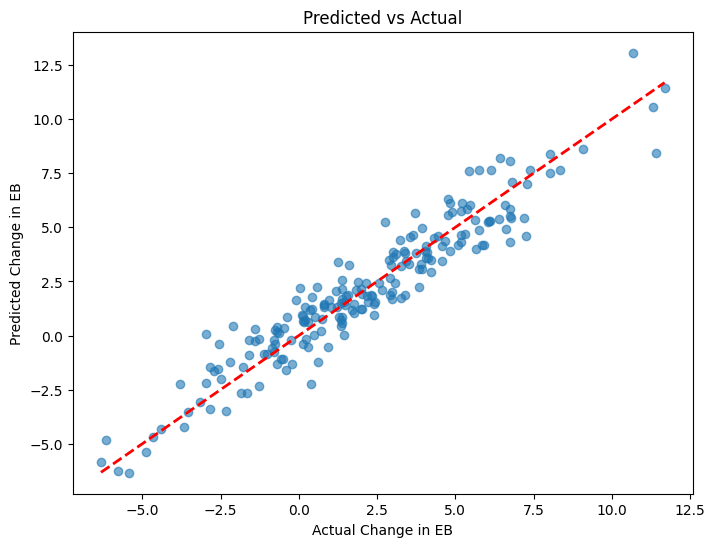

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2)  # 45-degree line
plt.xlabel("Actual Change in EB")
plt.ylabel("Predicted Change in EB")
plt.title("Predicted vs Actual")
plt.show()

## 6.5 - Plotting residuals

Residuals are the distance between the predicted values and the actual values. If they graph with a constant trend, that means a linear model was the best fit for our data. If not, it's a sign to try another model!

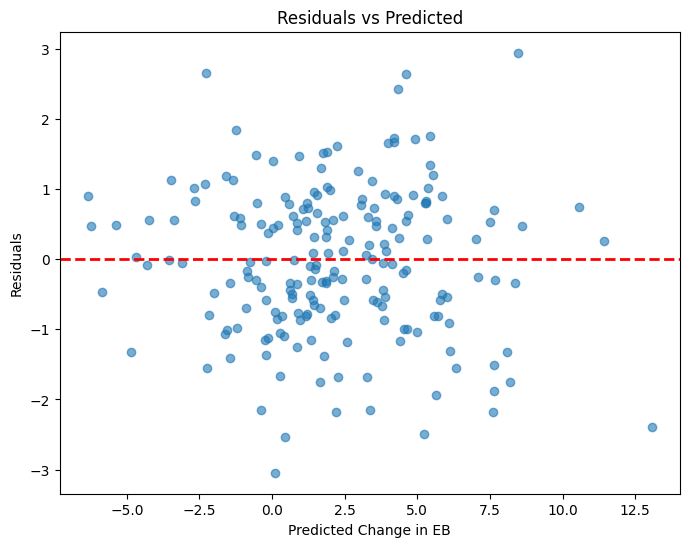

In [ ]:
residuals = y_test - y_pred

plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0, color='r', linestyle='--', linewidth=2)
plt.xlabel("Predicted Change in EB")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")
plt.show()

# Yay!!!! 🌞 🏠 😚 😎
### Congrats on creating an accurate model to predict how energy burden changes with solar energy adoption!